In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader

import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


## Загрузка и предобработка данных CIFAR-10

In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='./CIFAR10', train=True, download=False, transform=transform_train)
testset = torchvision.datasets.CIFAR10(
    root='./CIFAR10', train=False, download=False, transform=transform_test)

In [4]:
batch_size = 128
train_data = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
test_data = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

In [5]:
# Классы CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

In [6]:
print(f"Shape train data: {train_data.dataset.data.shape}")
print(f"Shape train data: {test_data.dataset.data.shape}")

Shape train data: (50000, 32, 32, 3)
Shape train data: (10000, 32, 32, 3)


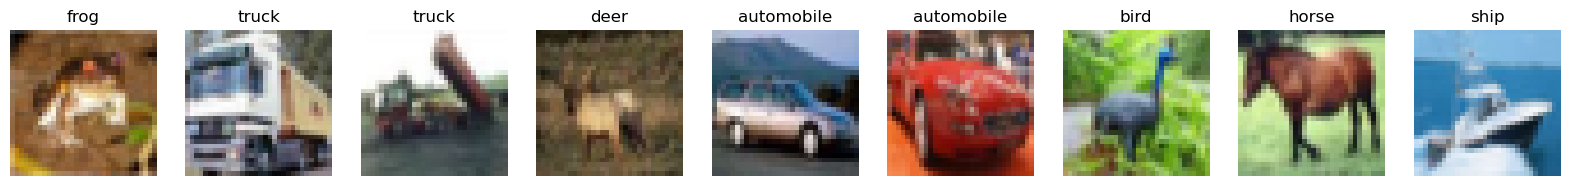

In [7]:
fig, ax = plt.subplots(1, 9, figsize = (20, 8))
for index in range(0, 9):
    ax[index].imshow(train_data.dataset.data[index])
    ax[index].axis("off")
    ax[index].set_title((train_data.dataset.classes[train_data.dataset.targets[index]]))

## Реализация сверточной нейронной сети

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        # Сверточные слои
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2)
        self.flatten = nn.Flatten()

        # Полносвязные слои
        self.fc1 = nn.Linear(64 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)

        # Dropout для регуляризации
        self.dropout = nn.Dropout(0.5)


    def forward(self, x):
        # Первый блок: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))

        # Второй блок: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))

        # Третий блок: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv3(x)))

        x = self.flatten(x)

        # Полносвязные слои
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Добавляем dropout для регуляризации
        x = self.fc2(x)

        return x

In [9]:
model = CNN(num_classes=10).to(device)
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## Функция потерь и оптимизатор

In [10]:
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

## Обучение модели

In [11]:
def train_model(model, data, loss, optimizer, num_epochs=25):
    train_losses = []
    train_accuracies = []

    time_start = time.time()

    for epoch in range(num_epochs):
        model.train()

        loss_epoch = []
        accuracy_epoch = []

        for batch_idx, (inputs, targets) in enumerate(data, 0):
            inputs, targets = inputs.to(device), targets.to(device)

            # Обнуление градиентов
            optimizer.zero_grad()

            # Прямой проход
            outputs = model(inputs)
            loss_batch = loss(outputs, targets)

            # Обратный проход и оптимизация
            loss_batch.backward()
            optimizer.step()

            loss_epoch.append(loss_batch)
            accuracy_epoch.append(torch.mean(torch.argmax(outputs, dim = 1) == targets, dtype = float))

        # Обновление learning rate
        scheduler.step()

        time_end = time.time()
        deltaTime = time_end - time_start

        print(f"Epoch {epoch + 1}/{num_epochs}, "
              f"Loss: {loss_batch.item():.3f}, "
              f"Accuracy: {torch.stack(accuracy_epoch).mean():.4f}, "
              f"Time: {deltaTime:.2f} s."
             )

        train_losses.append(torch.stack(loss_epoch).mean().cpu().detach().numpy())
        train_accuracies.append(torch.stack(accuracy_epoch).mean().cpu().detach().numpy())

    return train_losses, train_accuracies

In [12]:
num_epochs = 50
train_losses, train_accuracies = train_model(model, train_data, loss, optimizer, num_epochs)

Epoch 1/50, Loss: 1.449, Accuracy: 0.3892, Time: 53.58 s.
Epoch 2/50, Loss: 1.397, Accuracy: 0.5280, Time: 103.65 s.
Epoch 3/50, Loss: 1.063, Accuracy: 0.5931, Time: 153.72 s.
Epoch 4/50, Loss: 1.004, Accuracy: 0.6365, Time: 208.63 s.
Epoch 5/50, Loss: 0.948, Accuracy: 0.6649, Time: 261.27 s.
Epoch 6/50, Loss: 0.881, Accuracy: 0.6866, Time: 313.09 s.
Epoch 7/50, Loss: 0.908, Accuracy: 0.7028, Time: 365.26 s.
Epoch 8/50, Loss: 0.813, Accuracy: 0.7165, Time: 417.64 s.
Epoch 9/50, Loss: 0.656, Accuracy: 0.7231, Time: 475.80 s.
Epoch 10/50, Loss: 0.769, Accuracy: 0.7345, Time: 534.85 s.
Epoch 11/50, Loss: 0.666, Accuracy: 0.7555, Time: 592.65 s.
Epoch 12/50, Loss: 0.764, Accuracy: 0.7610, Time: 650.30 s.
Epoch 13/50, Loss: 0.841, Accuracy: 0.7659, Time: 706.61 s.
Epoch 14/50, Loss: 0.407, Accuracy: 0.7741, Time: 763.79 s.
Epoch 15/50, Loss: 0.499, Accuracy: 0.7756, Time: 820.76 s.
Epoch 16/50, Loss: 0.767, Accuracy: 0.7755, Time: 877.89 s.
Epoch 17/50, Loss: 0.621, Accuracy: 0.7798, Time: 

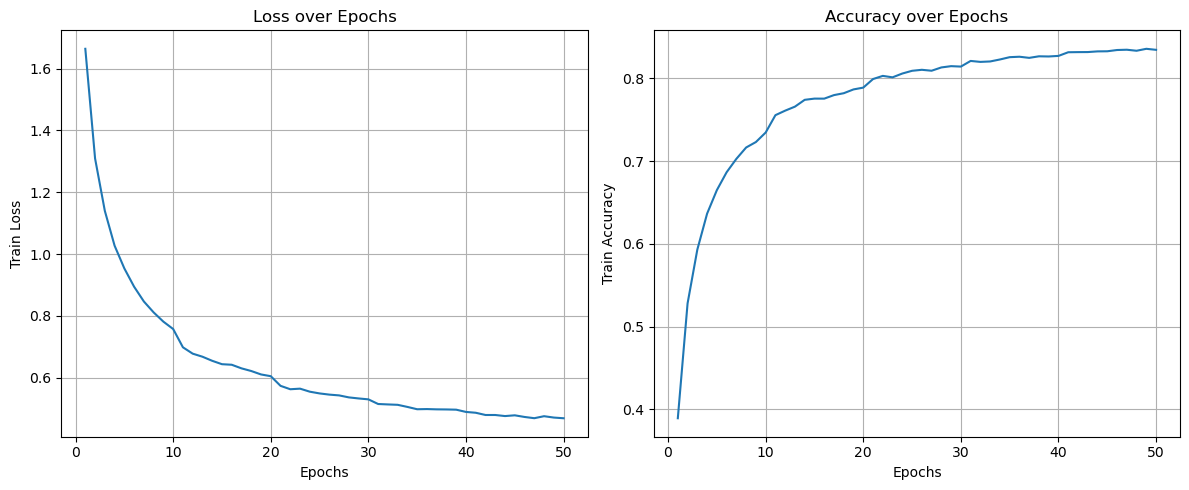

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses)
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Train Loss")
ax1.set_title("Loss over Epochs")
ax1.grid(True)

ax2.plot(epochs, train_accuracies)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Train Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [14]:
def test():
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    test_acc = 0.0

    with torch.no_grad():
        for inputs, targets in test_data:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            curr_loss = loss(outputs, targets)
            test_loss += curr_loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            test_acc += (predicted == targets).sum()

    print(f'Test Loss: {test_loss / total:.5f}')
    print(f'Test Accuracy: {test_acc / total:.5f}')

test()

Test Loss: 0.00393
Test Accuracy: 0.82770
